## Load packages

In [39]:
# import packages
import rioxarray as rxr
import xarray as xr
import numpy as np
import geopandas as gpd
from scipy.ndimage import generic_filter
import matplotlib.pyplot as plt
from rasterio.plot import show
from rasterio.features import rasterize
from rasterio.enums import Resampling
from pykrige.ok import OrdinaryKriging
from scipy.spatial import cKDTree

# set random seed
np.random.seed(42)

## Fix Scanlines

In [2]:
# set soc filepaths
soc_path = './carbon_stock_data/final_layers_clipped/soc_0_1m_kg_m2_sothe.tif'
soc_scanline_poly_path = './carbon_stock_data/soc_correction/scanline_polygon.shp'

In [3]:
# Load soc raster
soc = rxr.open_rasterio(soc_path).squeeze()  # drop band dim

# Mask nodata
nodata = soc.rio.nodata
if nodata is not None:
    soc = soc.where(soc != nodata)

# Get CRS
src_crs = soc.rio.crs

# Load scanline polygon
scanline_poly = gpd.read_file(soc_scanline_poly_path)
scanline_poly = scanline_poly.to_crs(src_crs)

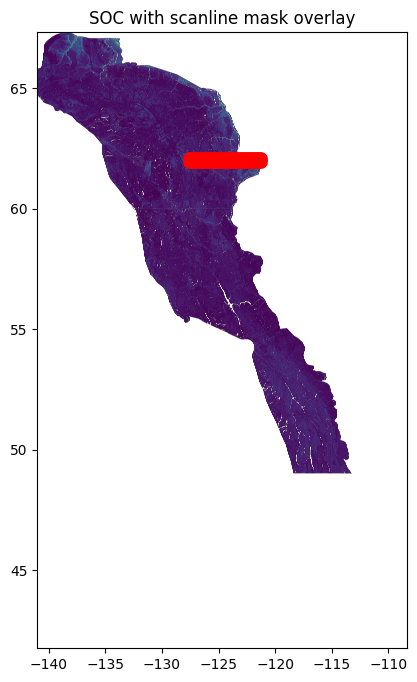

In [4]:
# check scanline mask overlay

fig, ax = plt.subplots(figsize=(8, 8))

# Plot raster
show(soc, transform=soc.rio.transform(), ax=ax, cmap="viridis")

# Plot vector on top
scanline_poly.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=10)

plt.title("SOC with scanline mask overlay")
plt.show()

In [5]:
# calculate the median of a 5x5 neighborhood
neighbor_median = soc.rolling(x=5, y=5, center=True).median(skipna=True)

diff = np.abs(soc - neighbor_median)

In [7]:
# Calculate the threshold for outlier pixels and mask outliers
mad = np.nanmedian(np.abs(diff - np.nanmedian(diff)))
threshold = 5 * mad
scan_mask = diff > threshold

In [8]:
# only keep outliers with at least 5 contiguous pixels
from scipy.ndimage import label

scan_mask_long = xr.zeros_like(scan_mask, dtype=bool)

for i in range(scan_mask.shape[0]):  # loop over rows
    row = scan_mask[i, :]
    labeled, n = label(row)
    for lab in range(1, n+1):
        idx = (labeled == lab)
        if idx.sum() >= 5:   # contiguous run length
            scan_mask_long[i, idx] = True

In [ ]:
# only keep outliers that fall within the scanline polygon
# first rasterize scanline polygon to a boolean "inside polygon" mask
scanline_mask = rasterize(
    ((geom, 1) for geom in scanline_poly.geometry if geom is not None and not geom.is_empty),
    out_shape=scan_mask_long.rio.shape,
    transform=scan_mask_long.rio.transform(),
    fill=0,
    all_touched=True,
    dtype='uint8'
).astype(bool)

# apply scanline mask to outlier mask
scan_mask_long = scan_mask_long & scanline_mask

In [10]:
# Define 3x3 footprint excluding center pixel
footprint = np.ones((3, 3), dtype=bool)
footprint[1, 1] = False

# Mask scanlines as NaN
soc_masked = soc.where(~scan_mask_long, np.nan)

# Median ignoring NaNs
neighbor_median = generic_filter(
    soc_masked,
    function=np.nanmedian,
    footprint=footprint,
    mode='constant',
    cval=np.nan
)

# Fill only scanline pixels
corrected = soc_masked.where(~scan_mask_long, neighbor_median)

/Users/ethanberman/Dropbox/Python Projects/y2y-carbon/.venv/lib/python3.14/site-packages/scipy/ndimage/_filters.py:2420: RuntimeWarning: All-NaN slice encountered
  _nd_image.generic_filter(input, function, footprint, output, mode,


In [ ]:
# export corrected raster and scanline mask to disk
corrected.rio.to_raster(
    "./carbon_stock_data/soc_correction/soc_scanline_corrected.tif",
    dtype="float32",
    nodata=np.nan,
)

scan_mask_long.rio.to_raster(
    "./carbon_stock_data/soc_correction/scanline_mask.tif",
    dtype="uint8"
)

## Fix SOC Artifact

In [82]:
# set filepaths

# soc scanline corrected
soc_path = './carbon_stock_data/soc_correction/soc_scanline_corrected.tif'

# ecosystem classification
eco_path = './irrecoverable_data/ecosystems_classification_250m.tif'

# soc artifact path
artifact_path = './carbon_stock_data/soc_correction/soc_artifact.shp'
buffer_path = './carbon_stock_data/soc_correction/soc_artifact_buffer.shp'

# set output paths
soc_out_path = './carbon_stock_data/soc_correction/soc_scanline_artifact_corrected.tif'
soc_mask_out_path = './carbon_stock_data/soc_correction/soc_artifact_mask.tif'

In [83]:
# set key parameters

# ecosystem classes to use
# Northern Forest (26), Northern Grasslands/Shrublands (29), Barren Lands (34)
eco_classes = [26,29,34] 

# IDW settings
k_neighbors = 32
power = 2
eps = 1e-12

# # kriging settings
# variogram_model = 'exponential'
# min_train_pts = 1000
# max_train_pts = 20000

# # optional: clip predictions to plausible range per class from buffer
# clip_to_buffer_percentiles = True
# clip_low, clip_high = 1, 99

In [84]:
# load rasters
soc = rxr.open_rasterio(soc_path, masked=True).squeeze()
eco = rxr.open_rasterio(eco_path, masked=True).squeeze()

# get CRS
print("soc crs:", soc.rio.crs, "shape:", soc.shape, "res:", soc.rio.resolution())
print("eco crs:", eco.rio.crs,  "shape:", eco.shape,  "res:", eco.rio.resolution())

soc crs: EPSG:4326 shape: (11386, 14570) res: (0.0022457898480768247, -0.0022457903991559697)
eco crs: PROJCS["WGS_1984_Lambert_Azimuthal_Equal_Area",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Lambert_Azimuthal_Equal_Area"],PARAMETER["latitude_of_center",45],PARAMETER["longitude_of_center",-100],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]] shape: (12854, 4705) res: (250.00000000000003, -250.00000000000003)


In [85]:
# resample eco to match soc
eco_match = eco.rio.reproject_match(
    soc,
    resampling=Resampling.nearest
)

print("soc crs:", soc.rio.crs, "res:", soc.rio.resolution())
print("eco_match crs:", eco_match.rio.crs, "res:", eco_match.rio.resolution())

soc crs: EPSG:4326 res: (0.0022457898480768247, -0.0022457903991559697)
eco_match crs: EPSG:4326 res: (0.0022457898480768247, -0.0022457903991559697)


In [90]:
# load soc and eco parameters
soc_shape = soc.rio.shape
soc_trans = soc.rio.transform()
soc_crs = soc.rio.crs
soc_vals = soc.values.astype("float32")
eco_vals = eco_match.values

In [91]:
# load artifact and buffer
# reproject to match soc
artifact = gpd.read_file(artifact_path).to_crs(soc_crs)
buffer = gpd.read_file(buffer_path).to_crs(soc_crs)

# rasterize artifact and buffer masks
artifact_mask = rasterize(
    [(geom, 1) for geom in artifact.geometry if geom is not None and not geom.is_empty],
    out_shape=soc_shape,
    transform=soc_trans,
    fill=0,
    dtype="uint8",
    all_touched=True
).astype("uint8")

buffer_mask = rasterize(
    [(geom, 1) for geom in buffer.geometry if geom is not None and not geom.is_empty],
    out_shape=soc_shape,
    transform=soc_trans,
    fill=0,
    dtype="uint8",
    all_touched=True
).astype("uint8")

# set prediction base and training base
pred_base  = artifact_mask == 1
finite_soc = np.isfinite(soc_vals)
train_base = (buffer_mask == 1) & (artifact_mask == 0) & finite_soc

print("Artifact pixels:", int(pred_base.sum()))
print("Training pixels (buffer, valid):", int(train_base.sum()))

Artifact pixels: 75132
Training pixels (buffer, valid): 121170


In [92]:
# ============================================================
# 3) Helper: row/col -> projected x,y coords (vectorized)
# ============================================================
def idx_to_xy(rows, cols, transform=soc_trans):
    # Affine: x = c + a*col + b*row ; y = f + d*col + e*row
    x = transform.c + cols * transform.a + rows * transform.b
    y = transform.f + cols * transform.d + rows * transform.e
    return x.astype("float64"), y.astype("float64")

In [93]:
# ============================================================
# 4) IDW function (kNN via KDTree)
# ============================================================
def idw_knn(xy_known, z_known, xy_pred, k=16, power=2):
    """
    Inverse Distance Weighting using k nearest neighbors.
    xy_known: (N,2), z_known: (N,), xy_pred: (M,2)
    Returns z_pred: (M,)
    """
    tree = cKDTree(xy_known)
    dists, idx = tree.query(xy_pred, k=min(k, len(z_known)))

    # Ensure 2D shape even if k=1
    if dists.ndim == 1:
        dists = dists[:, None]
        idx = idx[:, None]

    w = 1.0 / (np.maximum(dists, eps) ** power)
    z = z_known[idx]
    return (w * z).sum(axis=1) / w.sum(axis=1)

In [94]:
# ============================================================
# 5) IDW fill per landcover class
# ============================================================
filled = soc_vals.copy()
filled[pred_base] = np.nan

summary = []

for cls in eco_classes:
    train = train_base & (eco_vals == cls)
    pred  = pred_base  & (eco_vals == cls)

    n_train = int(train.sum())
    n_pred  = int(pred.sum())

    if n_pred == 0:
        summary.append((cls, n_train, n_pred, "skip (no pred)"))
        continue
    if n_train < 100:  # very small training sets will be unstable
        summary.append((cls, n_train, n_pred, "skip (too few train)"))
        continue

    # Known points
    r_t, c_t = np.where(train)
    x_t, y_t = idx_to_xy(r_t, c_t)
    xy_known = np.column_stack([x_t, y_t])
    z_known  = soc_vals[train].astype("float64")

    # Prediction points
    r_p, c_p = np.where(pred)
    x_p, y_p = idx_to_xy(r_p, c_p)
    xy_pred  = np.column_stack([x_p, y_p])

    print(f"[LC={cls}] train={n_train:,}, pred={n_pred:,} -> IDW(k={k_neighbors}, p={power})")

    z_pred = idw_knn(xy_known, z_known, xy_pred, k=k_neighbors, power=power).astype("float32")
    filled[r_p, c_p] = z_pred

    summary.append((cls, n_train, n_pred, "filled"))

summary

[LC=26] train=80,817, pred=54,169 -> IDW(k=32, p=2)
[LC=29] train=25,262, pred=15,649 -> IDW(k=32, p=2)
[LC=34] train=14,142, pred=3,855 -> IDW(k=32, p=2)


[(26, 80817, 54169, 'filled'),
 (29, 25262, 15649, 'filled'),
 (34, 14142, 3855, 'filled')]

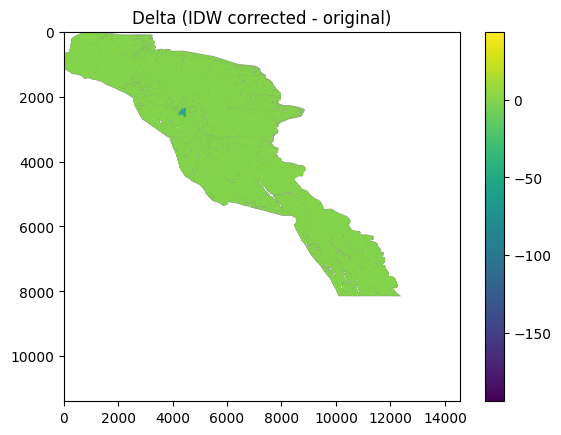

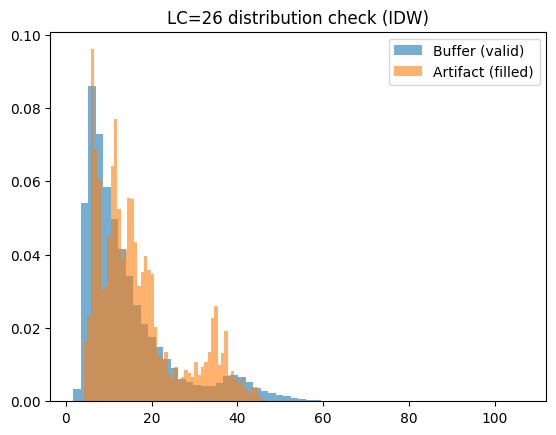

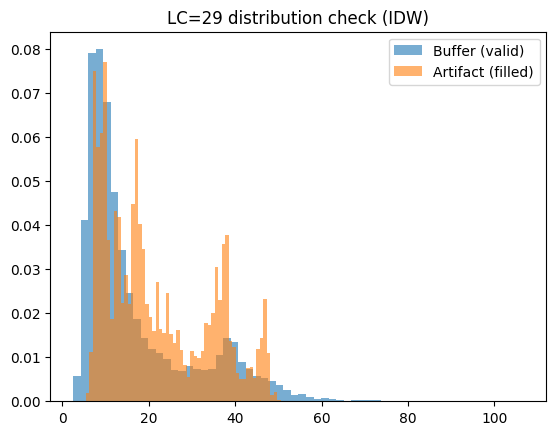

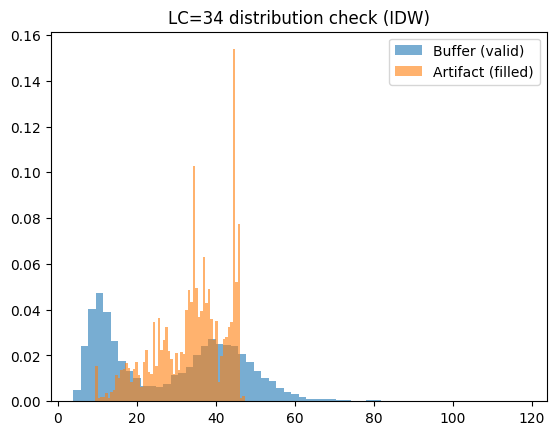

In [95]:
# ============================================================
# 6) Quick diagnostics: delta map + histograms per class
# ============================================================
delta = filled - soc_vals

plt.figure()
plt.imshow(delta, aspect="auto")
plt.title("Delta (IDW corrected - original)")
plt.colorbar()
plt.show()

for cls in eco_classes:
    buf = train_base & (eco_vals == cls)
    art = pred_base  & (eco_vals == cls)
    if buf.sum() == 0 or art.sum() == 0:
        continue

    plt.figure()
    plt.hist(soc_vals[buf][np.isfinite(soc_vals[buf])], bins=60, alpha=0.6, density=True, label="Buffer (valid)")
    plt.hist(filled[art][np.isfinite(filled[art])],     bins=60, alpha=0.6, density=True, label="Artifact (filled)")
    plt.title(f"LC={cls} distribution check (IDW)")
    plt.legend()
    plt.show()

In [101]:
# ============================================================
# 7) Export corrected raster + mask
# ============================================================
filled_da = xr.DataArray(filled, coords=soc.coords, dims=soc.dims, attrs=soc.attrs).rio.write_crs(soc.rio.crs)
mask_da   = xr.DataArray(artifact_mask, coords=soc.coords, dims=soc.dims).rio.write_crs(soc.rio.crs)

# set nodata explicitly to NaN
filled_da = filled_da.rio.write_nodata(soc.rio.nodata)
mask_da   = mask_da.rio.write_nodata(0)

filled_da.rio.to_raster(soc_out_path, compress="DEFLATE")
mask_da.rio.to_raster(soc_mask_out_path, compress="DEFLATE")

In [102]:
filled_da

<xarray.DataArray (y: 11386, x: 14570)> Size: 664MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(11386, 14570), dtype=float32)
Coordinates:
  * y            (y) float64 91kB 67.32 67.32 67.32 67.31 ... 41.76 41.75 41.75
  * x            (x) float64 117kB -141.0 -141.0 -141.0 ... -108.3 -108.3 -108.3
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes: (12/15)
    STATISTICS_APPROXIMATE:    YES
    STATISTICS_COUNT:          30929709.0
    STATISTICS_COVARIANCES:    411.260626391154
    STATISTICS_MAXIMUM:        385.24758911133
    STATISTICS_MEAN:           24.64547357691
    STATISTICS_MEDIAN:         17.332886
    ...                        ...
    STATISTICS_STDDEV:         20.279561789919
    STATISTICS_VALID_PERCENT:  18.44
    AREA_OR_POINT:             Area
    scale_factor:              1.0
    add_offset:                0.0
    _FillValue:                nan